In [1]:
from scipy.fft import fft

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
%config InlineBackend.figure_formats = ['svg']

import IPython.display as ipd

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


The introduction to quantization and quantization error showed that the quantization error is correlated with the input signal.
Athough this can be desirable for a distortion-like audio effect, it can be a problem in analog-digital conversion and bit-depth conversion.

*Dither* can be used to decorrelate the signal and the noise - it is additional noise that is added to the input signal before the quantization.


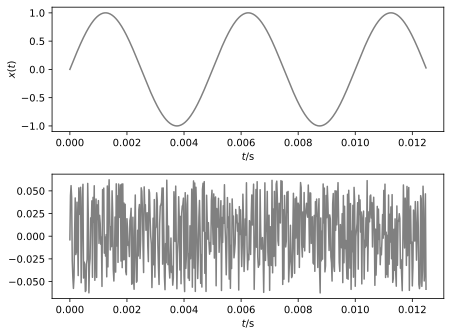

In [2]:
# 1000 Hz sampling rate
fs = 48000

# time vector with N samples length
N  = 2*fs
t  = np.linspace(0,N,N)/fs

f0 = 200

Nsteps = 8

x0  = np.sin(2*np.pi*f0*t)
y  = np.zeros(N)
e  = np.zeros(N)

vals  = np.linspace(-0.9,0.9,Nsteps)
steps = np.linspace(-1,1,Nsteps)

dither = 0.125*(np.random.random(N)-0.5) 

x=x0+dither



ax1 = plt.subplot(2,1,1)
ax1.plot(t[0:3*f0],x0[0:3*f0],'gray')

ax1.set_xlabel("$t / \mathrm{s}$")
ax1.set_ylabel("$x(t)$")


ax2 = plt.subplot(2,1,2)
ax2.plot(t[0:3*f0],dither[0:3*f0],'gray')
ax2.set_xlabel("$t / \mathrm{s}$")


plt.tight_layout()
plt.show()


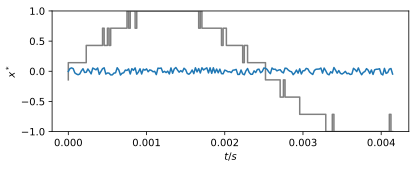

In [3]:


## Loop over all samples of x
for idx in range(N):
    i = np.abs(steps-x[idx]).argmin()
    y[idx] = steps[i]
    e[idx] = y[idx] - x[idx]

fig = plt.figure()
ax = fig.add_subplot(2, 1, 1)
ax.set_ylim(-1, 1)

line1, = ax.step(t[0:f0], y[0:f0], color = [0.5,0.5,0.5])
ax.plot(t[0:f0],dither[0:f0])
plt.xlabel('$t / s$')
plt.ylabel('$x^*$'); 

In [4]:
ipd.Audio(y, rate=fs)


# Quantization Error

The quantization error $e = x-x*$ shows a more stochastic bahavior in the time domain the the error without dither:

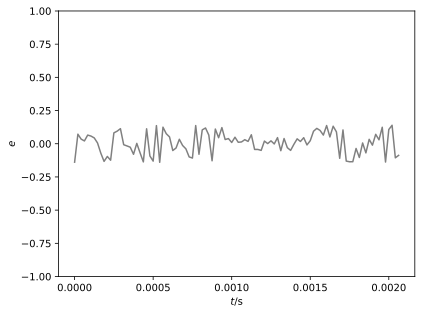

In [5]:
fig = plt.figure()
ax2 = fig.add_subplot(1, 1, 1)
ax2.set_ylim(-1, 1)    
line1, = ax2.plot(t[0:100], e[0:100], color = [0.5,0.5,0.5])
plt.xlabel('$t / \mathrm{s}$')
plt.ylabel('$e$'); 
 

## PDF of the Error

The PDF of the error after dithering is more uniformly distributed:

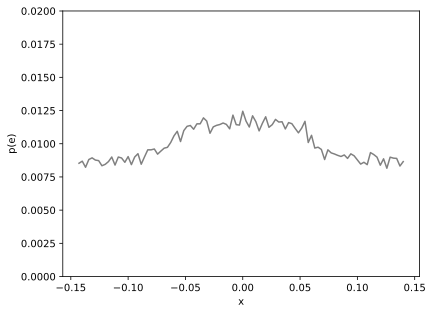

In [6]:
p,x = np.histogram(e,bins=100);
plt.plot(x[0:-1],p/sum(p),'gray')
plt.ylim([0,0.02])
plt.xlabel('x');
plt.ylabel('p(e)');

# Spectrum

The noise-floor is clearly visible in the spectrum. However, the higher partials of the distortion through quantization disappear:

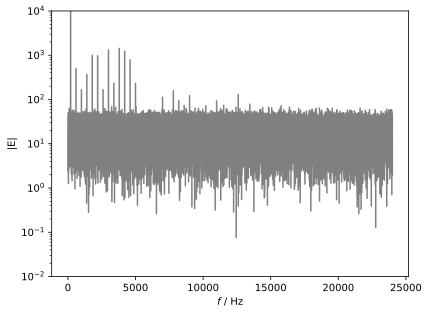

In [7]:

fig,ax = plt.subplots()

E = fft(e)[0:int(N/2)]
Y = fft(y)[0:int(N/2)]
f = np.linspace(0,fs/2,int(N/2))

plt.plot(f,abs(Y),'gray')

ax.set_yscale('log')
ax.set_ylim([0.01,10000])

plt.xlabel('$f $ / Hz')
plt.ylabel('|E|'); 

-------

# Noise Shaping

While the applied dither does change the qualities of the quantization, it does not necessarily improve them a lot for the 3-Bit case.
The noise - though now uncorrelated, is very dominant with this low SNR.
Noise shaping uses filters to *shape* the dither. If the sampling rate is high enough, it can be moved to frequncies outside the human hearing.

The plot below shows a high-pass filter with a cutoff frequency of $f_c = 0.7 f_s = 16800 \mathrm{Hz}$ and a steep slope (7th order Butterworth):


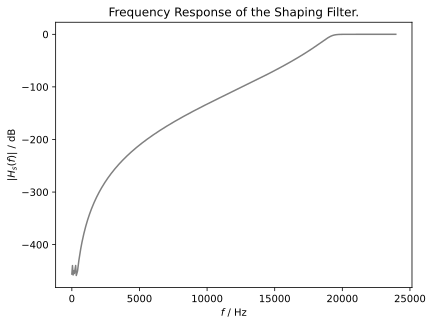

In [8]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
sr = 48000
b, a = signal.butter(11, 0.8, btype='high', analog=False)
w, h = signal.freqz(b, a)
x = w * sr * 1.0 / (2 * np.pi)
y = 20 * np.log10(abs(h))
plt.plot(x, y,'gray')
plt.ylabel('$|H_s(f)|$ / dB')
plt.xlabel('$f $ / Hz')
plt.title('Frequency Response of the Shaping Filter.')
#plt.grid(which='both', linestyle='-', color='grey')
#plt.xticks([20, 50, 100, 200, 500, 1000, 2000, 5000, 10000, 20000], ["20", "50", "100", "200", "500", "1K", "2K", "5K", "10K", "20K"])
plt.show()



----

The spectrum of the resulting signal shows a noise-floor that is rising towards higher frequencies.

In [9]:
# 1000 Hz sampling rate
fs = 48000

# time vector with N samples length
N  = 2*fs
t  = np.linspace(0,N,N)/fs

f0 = 200

Nsteps = 8

x0  = np.sin(2*np.pi*f0*t)
y  = np.zeros(N)
e  = np.zeros(N)

vals  = np.linspace(-0.9,0.9,Nsteps)
steps = np.linspace(-1,1,Nsteps)


dither = 0.125*(np.random.random(N)-0.5) 
dither = sp.signal.lfilter(b, a, dither)*2.5
x=x0+dither


## Loop over all samples of x
for idx in range(N):
    i = np.abs(steps-x[idx]).argmin()
    y[idx] = steps[i]
    e[idx] = y[idx] - x[idx]



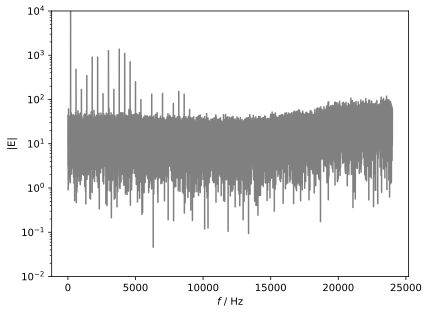

In [10]:
fig,ax = plt.subplots()

E = fft(e)[0:int(N/2)]
Y = fft(y)[0:int(N/2)]
f = np.linspace(0,fs/2,int(N/2))

plt.plot(f,abs(Y),'gray')

ax.set_yscale('log')
ax.set_ylim([0.01,10000])

plt.xlabel('$f $ / Hz')
plt.ylabel('|E|'); 

ipd.Audio(y, rate=fs)
